## PRVI DOMAĆI ZADATAK IZ ASTROSTATISTIKE
## Analiza magnetnog polja Sunčeve pege
#### Jasmina Hajtić 161/21



Uključujemo potrebne module:

In [19]:
# ============================================================
#  UVOZ MODULA
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from scipy.stats import norm, expon, uniform, laplace
from scipy.stats import skew, kurtosis
from scipy.optimize import curve_fit

# Podešavanje izgleda grafika.
# text.usetex=False znači da matplotlib neće tražiti instaliran LaTeX sistem.
matplotlib.rcParams.update({
    "text.usetex": False,
    "font.size": 10,
    "font.family": "monospace"
})

# Seed koristimo da bi nasumični izbori u proveri centralne granične teoreme
# bili ponovljivi pri svakom pokretanju koda.
np.random.seed(0)

Učitavamo fajl, prilagođavamo podatke potrebama zadatka i tspitujemo\
strukturu i dimenzije ulaznih podataka:

In [3]:
# ============================================================
#  UČITAVANJE PODATAKA IZ FAJLA
# ============================================================

# U zadatku je dat fajl sunspot.npz, koji sadrži tri 2D mape:
#   B   - jačina magnetnog polja |B| [G],
#   inc - inklinacija magnetnog polja [rad],
#   az  - azimut magnetnog polja [rad].
#
# Inklinaciju i azimut odmah pretvaramo iz radijana u stepene.

# Učitavanje .npz fajla.
data = np.load('sunspot.npz')

# Dvodimenziona mapa jačine magnetnog polja u gausima.
B_map = data['B']

# Dvodimenziona mapa inklinacije; u fajlu je u radijanima, pretvaramo u stepene.
theta_map = np.degrees(data['inc'])

# Dvodimenziona mapa azimuta; u fajlu je u radijanima, pretvaramo u stepene.
phi_map = np.degrees(data['az'])

# Za crtanje mapa koristimo 2D nizove.
# Za histograme, fitovanje i statistiku koristimo "spljoštene" 1D nizove.
B = B_map.ravel()
theta = theta_map.ravel()
phi = phi_map.ravel()

# Uklanjamo eventualne NaN i beskonačne vrednosti.
# Za svaki slučaj.
B = B[np.isfinite(B)]
theta = theta[np.isfinite(theta)]
phi = phi[np.isfinite(phi)]

# Struktura i dimenzije ulaznih podataka 
print('Oblik B mape:', B_map.shape)
print('Oblik theta mape:', theta_map.shape)
print('Oblik phi mape:', phi_map.shape)
print('Broj tačaka za analizu B:', len(B))
print('Broj tačaka za analizu theta:', len(theta))
print('Broj tačaka za analizu phi:', len(phi))

Oblik B mape: (64, 512)
Oblik theta mape: (64, 512)
Oblik phi mape: (64, 512)
Broj tačaka za analizu B: 32768
Broj tačaka za analizu theta: 32768
Broj tačaka za analizu phi: 32768


### ZADATAK 1

Potrebno je prikazati mape i histograme za parametre $|B|$, $\theta$ i $\phi$ pojedinačno.

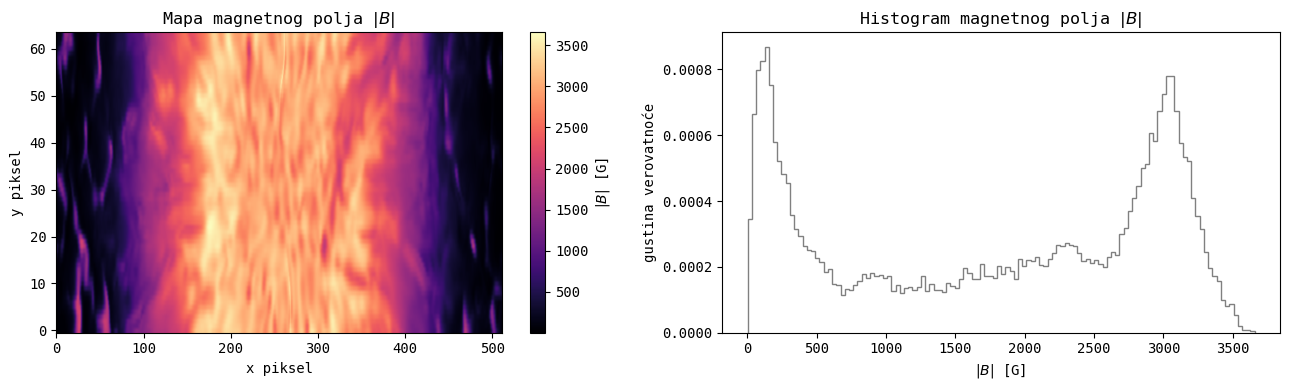

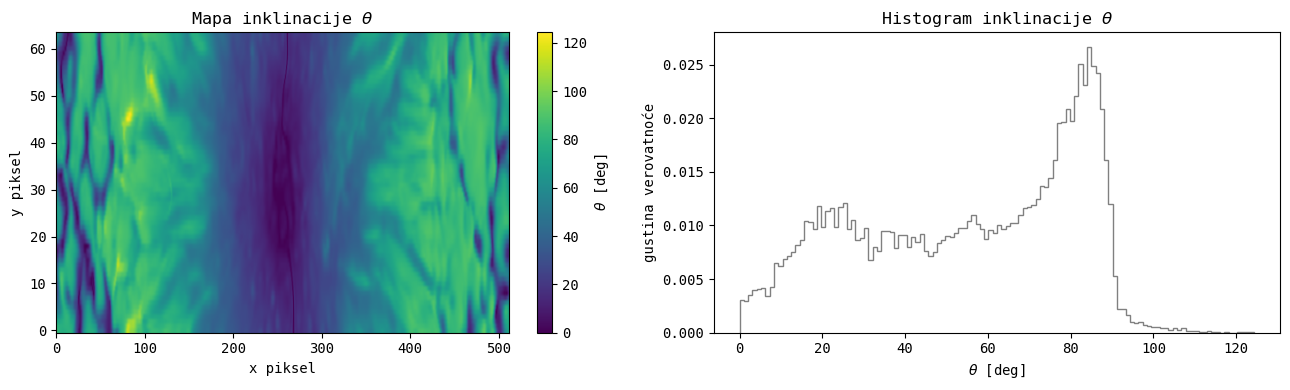

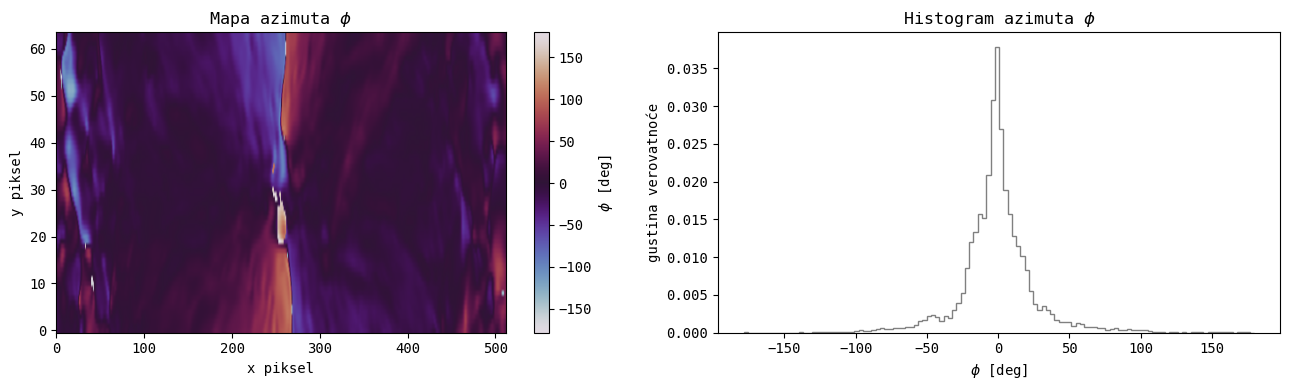

In [4]:
# ------------------------------------------------------------
# 1a) Mapa i histogram za jačinu magnetnog polja |B|
# ------------------------------------------------------------

plt.figure(figsize=(13, 4))

# Levo crtamo 2D mapu magnetnog polja.
plt.subplot(1, 2, 1)
im = plt.imshow(B_map, origin='lower', cmap='magma', aspect='auto')
plt.colorbar(im, label=r'$|B|$ [G]')
plt.xlabel('x piksel')
plt.ylabel('y piksel')
plt.title(r'Mapa magnetnog polja $|B|$')

# Desno crtamo normalizovani histogram vrednosti magnetnog polja.
plt.subplot(1, 2, 2)
plt.hist(B, bins=120, density=True, histtype='step', color='grey')
plt.xlabel(r'$|B|$ [G]')
plt.ylabel('gustina verovatnoće')
plt.title(r'Histogram magnetnog polja $|B|$')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 1b) Mapa i histogram za inklinaciju theta
# ------------------------------------------------------------

plt.figure(figsize=(13, 4))

# Levo crtamo 2D mapu inklinacije.
plt.subplot(1, 2, 1)
im = plt.imshow(theta_map, origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(im, label=r'$\theta$ [deg]')
plt.xlabel('x piksel')
plt.ylabel('y piksel')
plt.title(r'Mapa inklinacije $\theta$')

# Desno crtamo normalizovani histogram inklinacije.
plt.subplot(1, 2, 2)
plt.hist(theta, bins=120, density=True, histtype='step', color='grey')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('gustina verovatnoće')
plt.title(r'Histogram inklinacije $\theta$')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 1c) Mapa i histogram za azimut phi
# ------------------------------------------------------------

plt.figure(figsize=(13, 4))

# Levo crtamo 2D mapu azimuta.
plt.subplot(1, 2, 1)
im = plt.imshow(phi_map, origin='lower', cmap='twilight', aspect='auto')
plt.colorbar(im, label=r'$\phi$ [deg]')
plt.xlabel('x piksel')
plt.ylabel('y piksel')
plt.title(r'Mapa azimuta $\phi$')

# Desno crtamo normalizovani histogram azimuta.
plt.subplot(1, 2, 2)
plt.hist(phi, bins=120, density=True, histtype='step', color='grey')
plt.xlabel(r'$\phi$ [deg]')
plt.ylabel('gustina verovatnoće')
plt.title(r'Histogram azimuta $\phi$')

plt.tight_layout()
plt.show()



### ZADATAK 2

Potrebno je modelovati raspodele za posmatrane parametre:

- $|B|$ — kombinacija normalne, eksponencijalne i uniformne raspodele
- $\theta$ — kombinacija normalne i eksponencijalne raspodele
- $\phi$ — Laplasova raspodela

Preko histograma potrebno je nacrtati odgovarajuće modelne krive.

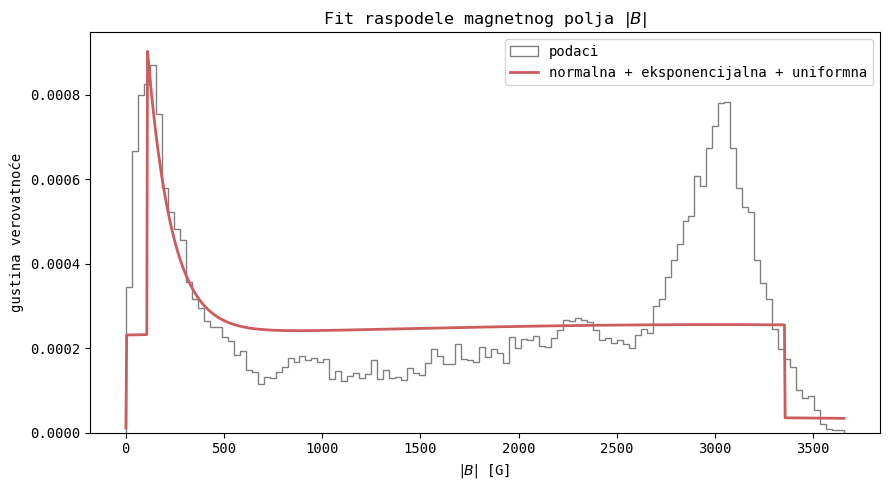


Parametri fita za B:
wN, muN, sigN, wE, locE, scaleE, wU, locU, widthU =
[2.12430323e-01 2.99784942e+03 1.96905577e+03 1.02543434e-01
 1.07969357e+02 1.24430569e+02 8.84290099e-01 1.33910775e+00
 3.35279842e+03]


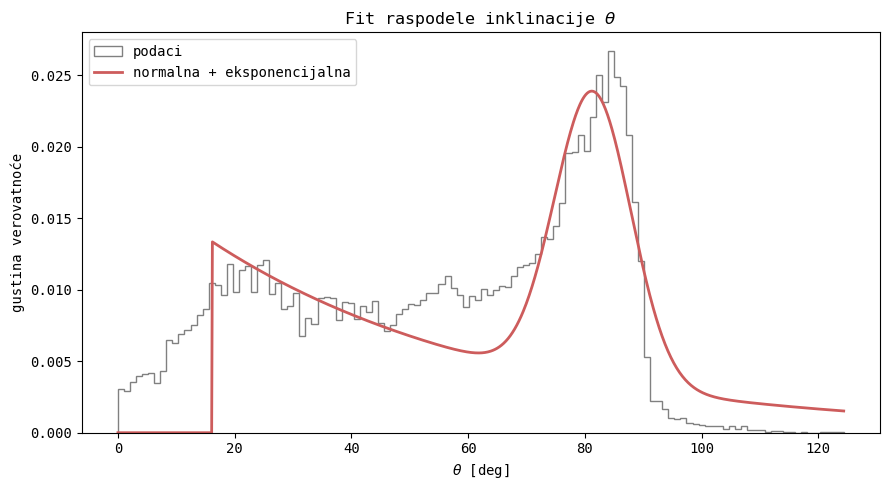


Parametri fita za theta:
wN, muN, sigN, wE, locE, scaleE =
[ 0.33789184 81.34248029  6.55684377  0.67544948 16.06262549 49.79641617]


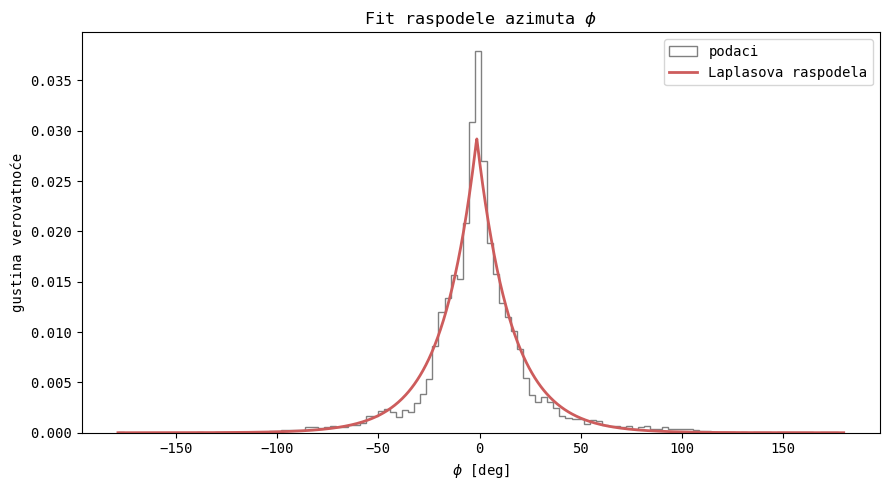


Parametri Laplasovog fita za phi:
loc  = -1.429375
scale= 17.089699


In [5]:
# ------------------------------------------------------------
# 2a) Model za B: normalna + eksponencijalna + uniformna
# ------------------------------------------------------------

# Definišemo model,
# Težine wN, wE i wU određuju relativni doprinos normalne,
# eksponencijalne i uniformne komponente.
def model_B(x, wN, muN, sigN, wE, locE, scaleE, wU, locU, widthU):
    weights_sum = wN + wE + wU

    normalni_deo = wN * norm.pdf(x, loc=muN, scale=sigN)
    eksponencijalni_deo = wE * expon.pdf(x, loc=locE, scale=scaleE)
    uniformni_deo = wU * uniform.pdf(x, loc=locU, scale=widthU)

    return (normalni_deo + eksponencijalni_deo + uniformni_deo) / weights_sum


# Pravimo histogram kao procenu gustine verovatnoće.
hist_B, edges_B = np.histogram(B, bins=120, density=True)
cent_B = 0.5 * (edges_B[1:] + edges_B[:-1])

# Početne procene parametara za fit.
B_min = np.min(B)
B_max = np.max(B)
B_mean = np.mean(B)
B_std = np.std(B, ddof=1)

p0_B = [
    0.5, B_mean, B_std,          # normalna komponenta: težina, sredina, sigma
    0.3, B_min, B_mean - B_min,  # eksponencijalna komponenta: težina, loc, scale
    0.2, B_min, B_max - B_min    # uniformna komponenta: težina, loc, širina
]

# Granice parametara. Ovim sprečavamo nefizičke vrednosti, npr. negativnu širinu.
bounds_B = (
    [1e-6, B_min, 1e-6, 1e-6, B_min, 1e-6, 1e-6, B_min, 1e-6],
    [1.0,  B_max, 5 * B_std, 1.0, B_max, 5 * B_std, 1.0, B_max, 2 * (B_max - B_min)]
)

# Fitujemo model na histogram.
popt_B, pcov_B = curve_fit(
    model_B,
    cent_B,
    hist_B,
    p0=p0_B,
    bounds=bounds_B,
    maxfev=50000
)

# Crtamo histogram i fitovani model.
x_B = np.linspace(B_min, B_max, 1000)
fit_B = model_B(x_B, *popt_B)

plt.figure(figsize=(9, 5))
plt.hist(B, bins=120, density=True, histtype='step', color='grey', label='podaci')
plt.plot(x_B, fit_B, color='indianred', lw=2,
         label='normalna + eksponencijalna + uniformna')
plt.xlabel(r'$|B|$ [G]')
plt.ylabel('gustina verovatnoće')
plt.title(r'Fit raspodele magnetnog polja $|B|$')
plt.legend()
plt.tight_layout()
plt.show()

print('\nParametri fita za B:')
print('wN, muN, sigN, wE, locE, scaleE, wU, locU, widthU =')
print(popt_B)


# ------------------------------------------------------------
# 2b) Model za theta: normalna + eksponencijalna
# ------------------------------------------------------------

# Definišemo model za inklinaciju.
def model_theta(x, wN, muN, sigN, wE, locE, scaleE):
    weights_sum = wN + wE

    normalni_deo = wN * norm.pdf(x, loc=muN, scale=sigN)
    eksponencijalni_deo = wE * expon.pdf(x, loc=locE, scale=scaleE)

    return (normalni_deo + eksponencijalni_deo) / weights_sum


# Histogram inklinacije kao procena gustine verovatnoće.
hist_theta, edges_theta = np.histogram(theta, bins=120, density=True)
cent_theta = 0.5 * (edges_theta[1:] + edges_theta[:-1])

theta_min = np.min(theta)
theta_max = np.max(theta)
theta_mean = np.mean(theta)
theta_std = np.std(theta, ddof=1)

p0_theta = [
    0.6, theta_mean, theta_std,              # normalna komponenta
    0.4, theta_min, theta_mean - theta_min   # eksponencijalna komponenta
]

bounds_theta = (
    [1e-6, theta_min, 1e-6, 1e-6, theta_min, 1e-6],
    [1.0,  theta_max, 5 * theta_std, 1.0, theta_max, 5 * theta_std]
)

# Fitovanje modela za theta.
popt_theta, pcov_theta = curve_fit(
    model_theta,
    cent_theta,
    hist_theta,
    p0=p0_theta,
    bounds=bounds_theta,
    maxfev=50000
)

# Crtanje histograma i modela.
x_theta = np.linspace(theta_min, theta_max, 1000)
fit_theta = model_theta(x_theta, *popt_theta)

plt.figure(figsize=(9, 5))
plt.hist(theta, bins=120, density=True, histtype='step', color='grey', label='podaci')
plt.plot(x_theta, fit_theta, color='indianred', lw=2,
         label='normalna + eksponencijalna')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('gustina verovatnoće')
plt.title(r'Fit raspodele inklinacije $\theta$')
plt.legend()
plt.tight_layout()
plt.show()

print('\nParametri fita za theta:')
print('wN, muN, sigN, wE, locE, scaleE =')
print(popt_theta)


# ------------------------------------------------------------
# 2c) Model za phi: Laplasova raspodela
# ------------------------------------------------------------

# Po zadatku, azimut phi modelujemo Laplasovom raspodelom.
# Metoda laplace.fit procenjuje parametre loc i scale.
phi_loc, phi_scale = laplace.fit(phi)

phi_min = np.min(phi)
phi_max = np.max(phi)
x_phi = np.linspace(phi_min, phi_max, 1000)
fit_phi = laplace.pdf(x_phi, loc=phi_loc, scale=phi_scale)

plt.figure(figsize=(9, 5))
plt.hist(phi, bins=120, density=True, histtype='step', color='grey', label='podaci')
plt.plot(x_phi, fit_phi, color='indianred', lw=2, label='Laplasova raspodela')
plt.xlabel(r'$\phi$ [deg]')
plt.ylabel('gustina verovatnoće')
plt.title(r'Fit raspodele azimuta $\phi$')
plt.legend()
plt.tight_layout()
plt.show()

print('\nParametri Laplasovog fita za phi:')
print('loc  =', phi_loc)
print('scale=', phi_scale)


### ZADATAK 3

Za svaki od parametara potrebno je odrediti:

- srednju vrednost
- standardnu devijaciju
- medijanu
- $\sigma_G = q_{75} - q_{25}$
- skewness
- kurtosis

Srednju vrednost i medijanu potrebno je prikazati kao vertikalne linije na histogramima.

Takođe, potrebno je komentarisati robusnost deskriptivnih statistika.


Deskriptivna statistika za |B| [G]
Srednja vrednost      = 1795.6
Standardna devijacija = 1163.69
Medijana              = 2043.23
sigma_G = q75 - q25   = 2407.12
Skewness              = -0.240945
Kurtosis              = -1.50213


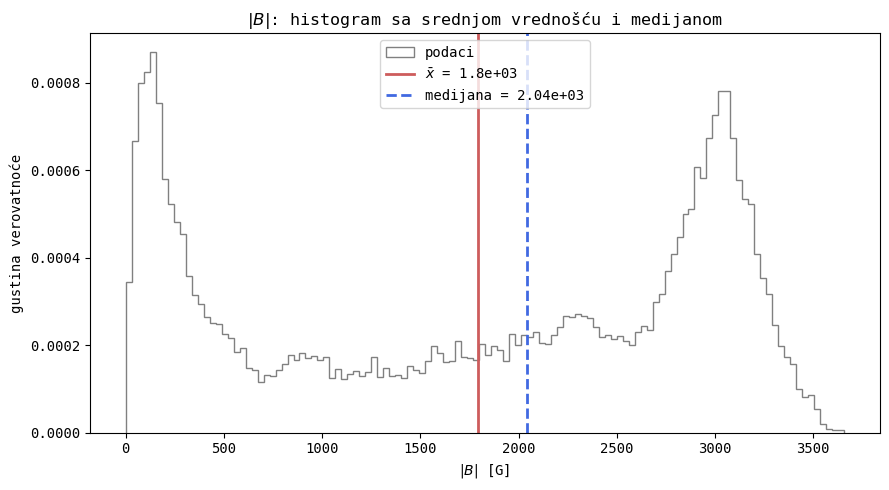


Deskriptivna statistika za theta [deg]
Srednja vrednost      = 55.362
Standardna devijacija = 26.3059
Medijana              = 59.8523
sigma_G = q75 - q25   = 47.6992
Skewness              = -0.337298
Kurtosis              = -1.17602


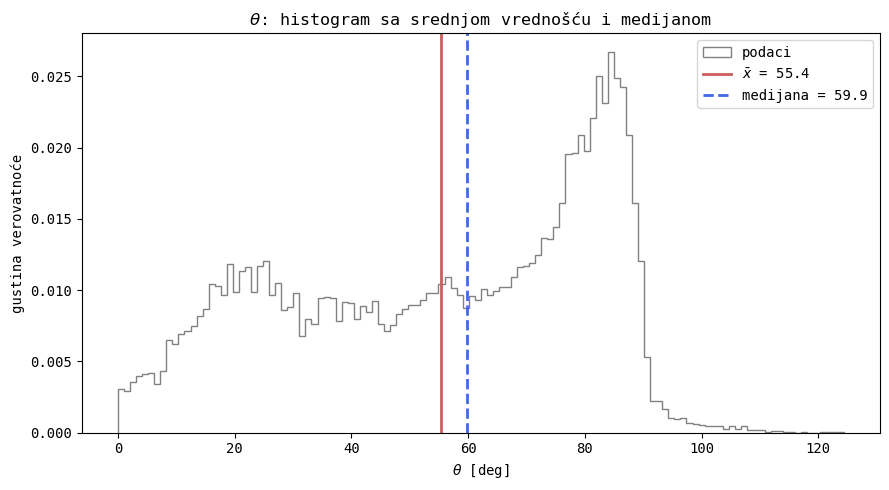


Deskriptivna statistika za phi [deg]
Srednja vrednost      = -0.568734
Standardna devijacija = 26.8185
Medijana              = -1.42938
sigma_G = q75 - q25   = 21.1047
Skewness              = 0.442748
Kurtosis              = 5.73542


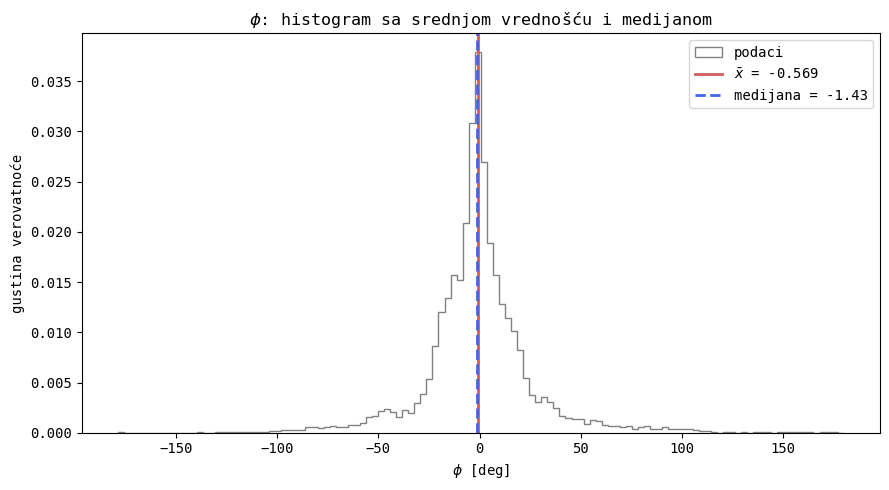

In [8]:
# ------------------------------------------------------------
# 3a) Deskriptivna statistika za B
# ------------------------------------------------------------

B_mean = np.mean(B)
B_std = np.std(B, ddof=1)
B_median = np.median(B)
B_q25, B_q75 = np.percentile(B, [25, 75])
B_sigma_G = B_q75 - B_q25
B_skew = skew(B)
B_kurtosis = kurtosis(B)

print('\n' + '=' * 60)
print('Deskriptivna statistika za |B| [G]')
print('=' * 60)
print(f'Srednja vrednost      = {B_mean:.6g}')
print(f'Standardna devijacija = {B_std:.6g}')
print(f'Medijana              = {B_median:.6g}')
print(f'sigma_G = q75 - q25   = {B_sigma_G:.6g}')
print(f'Skewness              = {B_skew:.6g}')
print(f'Kurtosis              = {B_kurtosis:.6g}')

plt.figure(figsize=(9, 5))
plt.hist(B, bins=120, density=True, histtype='step', color='grey', label='podaci')
plt.axvline(B_mean, color='indianred', lw=2,
            label=r'$\bar{{x}}$ = {:.3g}'.format(B_mean))
plt.axvline(B_median, color='royalblue', lw=2, ls='--',
            label='medijana = {:.3g}'.format(B_median))
plt.xlabel(r'$|B|$ [G]')
plt.ylabel('gustina verovatnoće')
plt.title(r'$|B|$: histogram sa srednjom vrednošću i medijanom')
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3b) Deskriptivna statistika za theta
# ------------------------------------------------------------

theta_mean = np.mean(theta)
theta_std = np.std(theta, ddof=1)
theta_median = np.median(theta)
theta_q25, theta_q75 = np.percentile(theta, [25, 75])
theta_sigma_G = theta_q75 - theta_q25
theta_skew = skew(theta)
theta_kurtosis = kurtosis(theta)

print('\n' + '=' * 60)
print('Deskriptivna statistika za theta [deg]')
print('=' * 60)
print(f'Srednja vrednost      = {theta_mean:.6g}')
print(f'Standardna devijacija = {theta_std:.6g}')
print(f'Medijana              = {theta_median:.6g}')
print(f'sigma_G = q75 - q25   = {theta_sigma_G:.6g}')
print(f'Skewness              = {theta_skew:.6g}')
print(f'Kurtosis              = {theta_kurtosis:.6g}')

plt.figure(figsize=(9, 5))
plt.hist(theta, bins=120, density=True, histtype='step', color='grey', label='podaci')
plt.axvline(theta_mean, color='indianred', lw=2,
            label=r'$\bar{{x}}$ = {:.3g}'.format(theta_mean))
plt.axvline(theta_median, color='royalblue', lw=2, ls='--',
            label='medijana = {:.3g}'.format(theta_median))
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel('gustina verovatnoće')
plt.title(r'$\theta$: histogram sa srednjom vrednošću i medijanom')
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3c) Deskriptivna statistika za phi
# ------------------------------------------------------------

phi_mean = np.mean(phi)
phi_std = np.std(phi, ddof=1)
phi_median = np.median(phi)
phi_q25, phi_q75 = np.percentile(phi, [25, 75])
phi_sigma_G = phi_q75 - phi_q25
phi_skew = skew(phi)
phi_kurtosis = kurtosis(phi)

print('\n' + '=' * 60)
print('Deskriptivna statistika za phi [deg]')
print('=' * 60)
print(f'Srednja vrednost      = {phi_mean:.6g}')
print(f'Standardna devijacija = {phi_std:.6g}')
print(f'Medijana              = {phi_median:.6g}')
print(f'sigma_G = q75 - q25   = {phi_sigma_G:.6g}')
print(f'Skewness              = {phi_skew:.6g}')
print(f'Kurtosis              = {phi_kurtosis:.6g}')

plt.figure(figsize=(9, 5))
plt.hist(phi, bins=120, density=True, histtype='step', color='grey', label='podaci')
plt.axvline(phi_mean, color='indianred', lw=2,
            label=r'$\bar{{x}}$ = {:.3g}'.format(phi_mean))
plt.axvline(phi_median, color='royalblue', lw=2, ls='--',
            label='medijana = {:.3g}'.format(phi_median))
plt.xlabel(r'$\phi$ [deg]')
plt.ylabel('gustina verovatnoće')
plt.title(r'$\phi$: histogram sa srednjom vrednošću i medijanom')
plt.legend()
plt.tight_layout()
plt.show()





### Komentar robusnosti deskriptivnih statistika

Za magnetno polje $|B|$ dobijena je srednja vrednost 1795.6 G, standardna devijacija 1163.69 G, medijana 2043.23 G i $\sigma_G = 2407.12$ G. Razlika između srednje vrednosti i medijane pokazuje da raspodela nije simetrična. Negativan skewness ($-0.24$) ukazuje na asimetriju ka manjim vrednostima, odnosno na produžen levi rep. Kurtosis je negativan ($-1.50$), što znači da je raspodela spljoštenija od normalne i da nema izražen centralni pik. Velika standardna devijacija i velika $\sigma_G$ ukazuju na široku raspodelu. U ovom slučaju medijana i $\sigma_G$ daju robusniji opis tipične vrednosti i rasipanja nego srednja vrednost i standardna devijacija.

Za inklinaciju $\theta$ dobijena je srednja vrednost $55.36^\circ$, standardna devijacija $26.31^\circ$, medijana $59.85^\circ$ i $\sigma_G = 47.70^\circ$. Srednja vrednost i medijana su relativno bliske, ali razlika i dalje postoji, što ukazuje na blagu asimetriju (skewness = $-0.34$). Kurtosis je negativan ($-1.18$), pa je raspodela ravnija u odnosu na normalnu. Standardna devijacija i $\sigma_G$ pokazuju značajno rasipanje. Pošto raspodela nije potpuno simetrična, medijana i $\sigma_G$ su pouzdanije robusne mere.

Za azimut $\phi$ srednja vrednost ($-0.57^\circ$) i medijana ($-1.43^\circ$) su veoma bliske, što ukazuje na približno simetričnu raspodelu u centralnom delu. Međutim, skewness je pozitivan ($0.44$), a kurtosis je veoma visok ($5.74$), što znači da raspodela ima izražen centralni pik i teške repove. To ukazuje na prisustvo ekstremnih vrednosti. U takvim uslovima standardna devijacija može biti pod uticajem repova, dok $\sigma_G$ daje stabilniju procenu rasipanja.

Zaključno, srednja vrednost i standardna devijacija su osetljive na asimetriju i ekstremne vrednosti, dok su medijana i $\sigma_G$ robusnije statistike. Skewness opisuje smer i jačinu asimetrije, a kurtosis govori o izraženosti repova raspodele. Na osnovu dobijenih rezultata, raspodele $|B|$ i $\theta$ su blago asimetrične i spljoštene, dok $\phi$ ima izražen centralni pik i teške repove, pa su u njegovom slučaju robusne mere posebno značajne.

### ZADATAK 4

Provera centralne granične teoreme za sva tri parametra: $|B|$, $\theta$ i $\phi$.

Centralna granična teorema kaže da se raspodela srednjih vrednosti uzoraka približava normalnoj raspodeli kada veličina uzorka raste.

Za svaki parametar uzimamo veliki broj nasumičnih uzoraka veličine $n$, računamo njihove srednje vrednosti i posmatramo kako izgleda raspodela tih srednjih vrednosti.

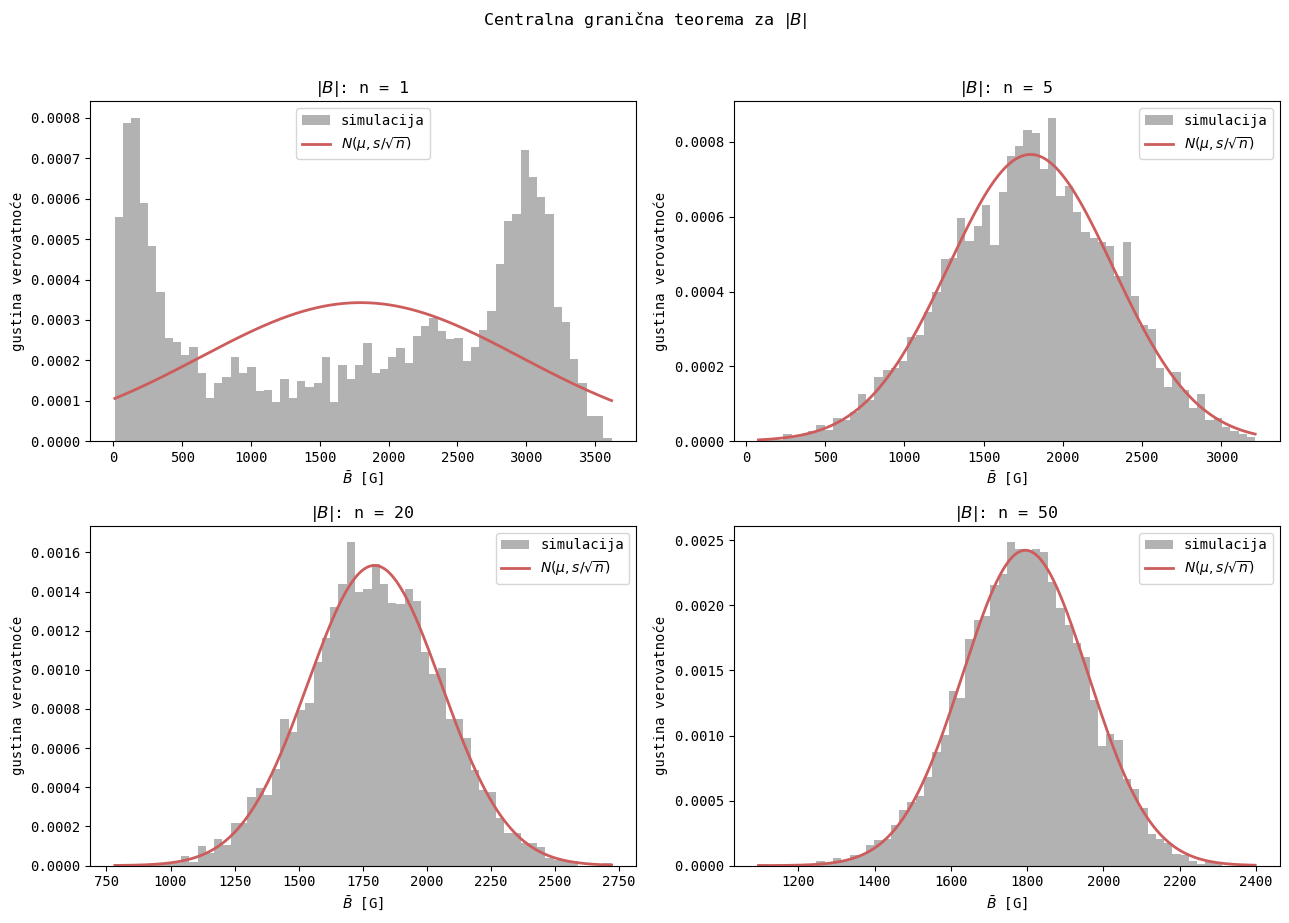

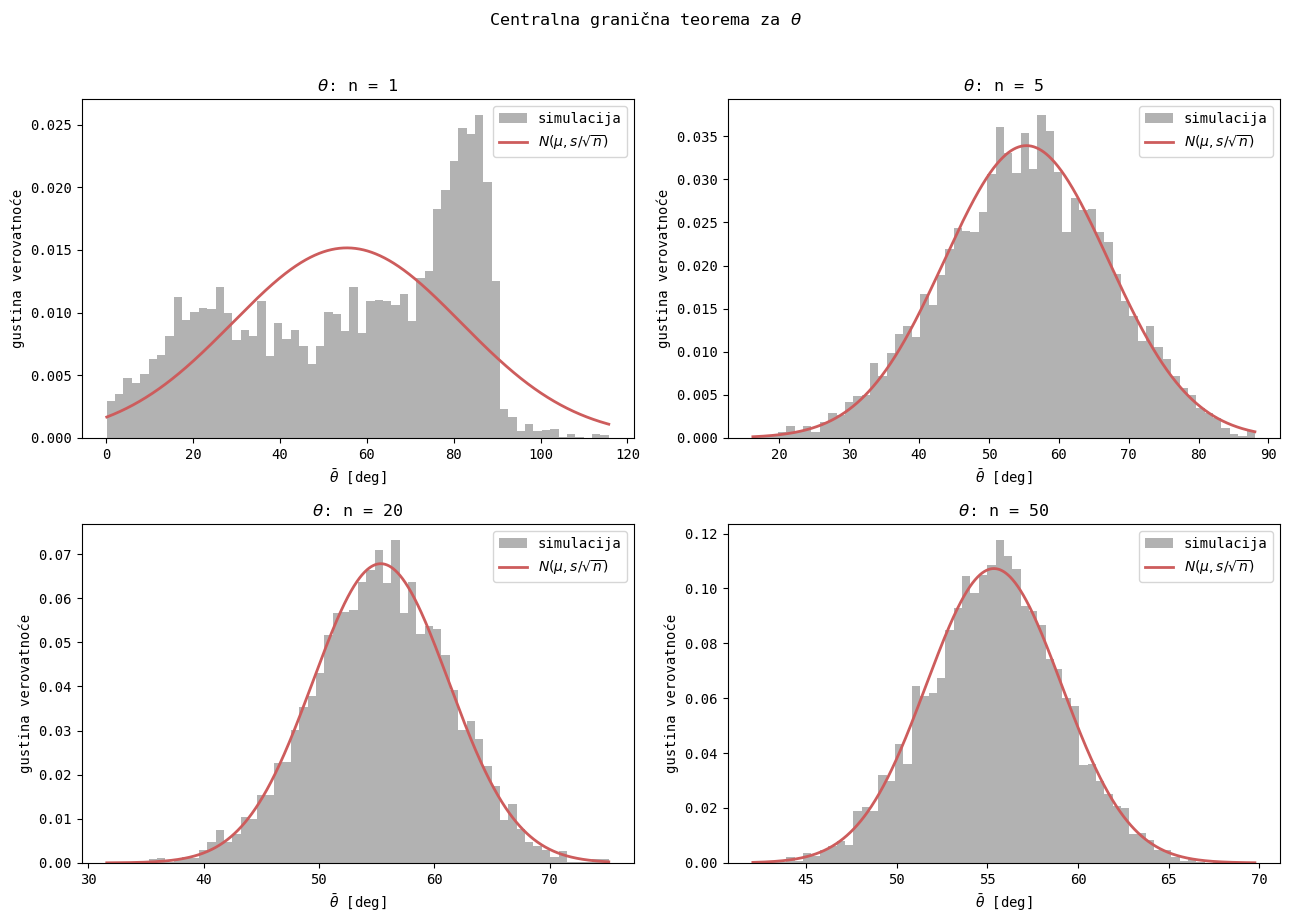

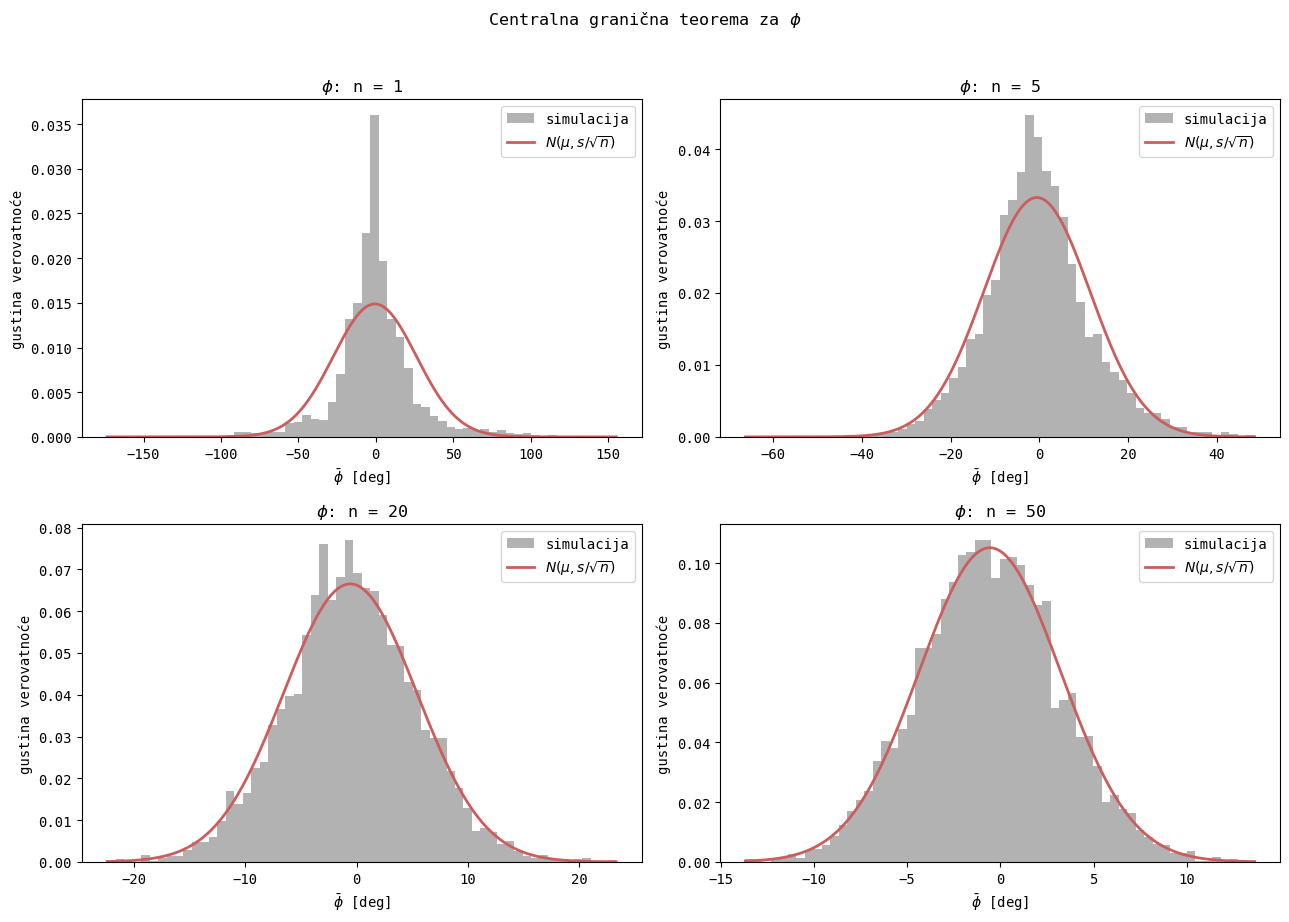

In [13]:
# Zadajemo vrednosti:
velicine_uzorka = [1, 5, 20, 50]
broj_ponavljanja = 5000

# ------------------------------------------------------------
# 4a) CGT za magnetno polje B
# ------------------------------------------------------------

B_mu = np.mean(B)
B_s = np.std(B, ddof=1)

plt.figure(figsize=(13, 9))

for i, n in enumerate(velicine_uzorka):
    B_sredine = []

    for j in range(broj_ponavljanja):
        uzorak = np.random.choice(B, size=n, replace=True)
        B_sredine.append(np.mean(uzorak))

    B_sredine = np.array(B_sredine)

    sigma_sredine = B_s / np.sqrt(n)
    x_pdf = np.linspace(np.min(B_sredine), np.max(B_sredine), 1000)
    pdf = norm.pdf(x_pdf, loc=B_mu, scale=sigma_sredine)

    plt.subplot(2, 2, i + 1)
    plt.hist(B_sredine, bins=60, density=True, histtype='stepfilled',
             color='grey', alpha=0.6, label='simulacija')
    plt.plot(x_pdf, pdf, color='indianred', lw=2,
             label=r'$N(\mu, s/\sqrt{n})$')
    plt.xlabel(r'$\bar{B}$ [G]')
    plt.ylabel('gustina verovatnoće')
    plt.title(r'$|B|$: n = {}'.format(n))
    plt.legend()

plt.suptitle(r'Centralna granična teorema za $|B|$', y=1.02)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4b) CGT za inklinaciju theta
# ------------------------------------------------------------

theta_mu = np.mean(theta)
theta_s = np.std(theta, ddof=1)

plt.figure(figsize=(13, 9))

for i, n in enumerate(velicine_uzorka):
    theta_sredine = []

    for j in range(broj_ponavljanja):
        uzorak = np.random.choice(theta, size=n, replace=True)
        theta_sredine.append(np.mean(uzorak))

    theta_sredine = np.array(theta_sredine)

    sigma_sredine = theta_s / np.sqrt(n)
    x_pdf = np.linspace(np.min(theta_sredine), np.max(theta_sredine), 1000)
    pdf = norm.pdf(x_pdf, loc=theta_mu, scale=sigma_sredine)

    plt.subplot(2, 2, i + 1)
    plt.hist(theta_sredine, bins=60, density=True, histtype='stepfilled',
             color='grey', alpha=0.6, label='simulacija')
    plt.plot(x_pdf, pdf, color='indianred', lw=2,
             label=r'$N(\mu, s/\sqrt{n})$')
    plt.xlabel(r'$\bar{\theta}$ [deg]')
    plt.ylabel('gustina verovatnoće')
    plt.title(r'$\theta$: n = {}'.format(n))
    plt.legend()

plt.suptitle(r'Centralna granična teorema za $\theta$', y=1.02)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4c) CGT za azimut phi
# ------------------------------------------------------------

phi_mu = np.mean(phi)
phi_s = np.std(phi, ddof=1)

plt.figure(figsize=(13, 9))

for i, n in enumerate(velicine_uzorka):
    phi_sredine = []

    for j in range(broj_ponavljanja):
        uzorak = np.random.choice(phi, size=n, replace=True)
        phi_sredine.append(np.mean(uzorak))

    phi_sredine = np.array(phi_sredine)

    sigma_sredine = phi_s / np.sqrt(n)
    x_pdf = np.linspace(np.min(phi_sredine), np.max(phi_sredine), 1000)
    pdf = norm.pdf(x_pdf, loc=phi_mu, scale=sigma_sredine)

    plt.subplot(2, 2, i + 1)
    plt.hist(phi_sredine, bins=60, density=True, histtype='stepfilled',
             color='grey', alpha=0.6, label='simulacija')
    plt.plot(x_pdf, pdf, color='indianred', lw=2,
             label=r'$N(\mu, s/\sqrt{n})$')
    plt.xlabel(r'$\bar{\phi}$ [deg]')
    plt.ylabel('gustina verovatnoće')
    plt.title(r'$\phi$: n = {}'.format(n))
    plt.legend()

plt.suptitle(r'Centralna granična teorema za $\phi$', y=1.02)
plt.tight_layout()
plt.show()


### Komentar za centralnu graničnu teoremu

Za sva tri parametra $|B|$, $\theta$ i $\phi$ izvršena je numerička provera centralne granične teoreme tako što su formirani uzorci različitih veličina $n = 1, 5, 20, 50$, a zatim su analizirane raspodele njihovih srednjih vrednosti.

Za $n = 1$ raspodela srednjih vrednosti odgovara originalnoj raspodeli podataka. To se jasno vidi na svim grafikonima, posebno za magnetno polje $|B|$, gde raspodela ima složen oblik sa više maksimuma, kao i za $\theta$, gde je raspodela asimetrična. Kod $\phi$ se uočava izražen centralni pik.

Kako se veličina uzorka povećava ($n = 5, 20, 50$), raspodele srednjih vrednosti postaju sve glađe i sve bolje se aproksimiraju normalnom raspodelom. Ovo se vidi po tome što histogrami sve više poprimaju zvonolik oblik i dobro se poklapaju sa teorijskom krivom $N(\mu, s/\sqrt{n})$.

Istovremeno, širina raspodele srednjih vrednosti opada sa porastom $n$, što je u skladu sa teorijskim rezultatom da standardna devijacija srednje vrednosti iznosi $s/\sqrt{n}$. To se posebno jasno vidi kod većih uzoraka ($n = 20$ i $n = 50$), gde su raspodele znatno uže i koncentrisane oko srednje vrednosti.

Važno je istaći da centralna granična teorema važi bez obzira na oblik početne raspodele. To se u ovom primeru jasno potvrđuje, jer i za nesimetrične i složene raspodele kao što su $|B|$ i $\theta$, kao i za raspodelu sa izraženim pikom i repovima kao što je $\phi$, raspodele srednjih vrednosti teže normalnoj raspodeli za dovoljno veliko $n$.

Zaključno, rezultati numeričke simulacije potvrđuju centralnu graničnu teoremu: bez obzira na početni oblik raspodele, raspodela srednjih vrednosti uzoraka teži normalnoj raspodeli, dok se njena širina smanjuje sa porastom veličine uzorka.

### ZADATAK 5

Magnetni pritisak definisan je izrazom:

$P = \frac{B^2}{2\mu_0}$

gde je $B$ jačina magnetnog polja izražena u teslama.

Potrebno je uporediti $s_P$ dobijeno propagacijom greške sa direktno izračunatim $s_P$ iz raspodele $P$.


Magnetni pritisak
mu0 = 1.256637e-06 H/m
Srednje B = 1.795597e-01 T
s_B = 1.163692e-01 T
Srednji magnetni pritisak = 1.821650e+04 Pa
s_P direktno iz P = 1.574062e+04 Pa
s_P propagacijom = 1.662789e+04 Pa
Apsolutno odstupanje = 8.872676e+02 Pa
Relativno odstupanje = 5.636802%


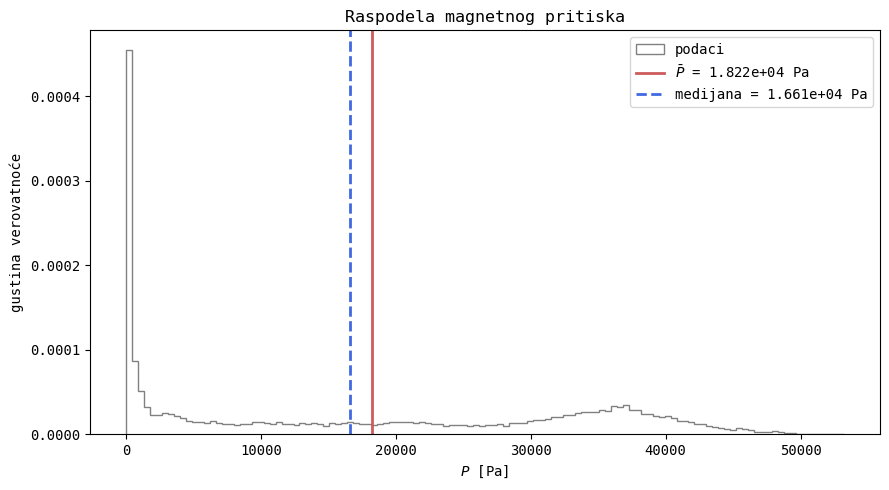

In [20]:
# Magnetna permeabilnost vakuuma.
mu0 = 4 * np.pi * 1e-7  # [H/m]

# Podaci za B su u gausima, a za formulu za magnetni pritisak B mora biti u teslama.
# Konverzija je: 1 G = 1e-4 T.
B_T = B * 1e-4

# Magnetni pritisak za svaku tačku mape.
P = B_T**2 / (2 * mu0)

# Direktno računamo standardnu devijaciju pritiska iz niza P.
sP_direktno = np.std(P, ddof=1)

# Standardna devijacija magnetnog polja u teslama.
sB = np.std(B_T, ddof=1)

# Pošto je:
#       P(B) = B^2 / (2 mu0),
# izvod je:
#       dP/dB = B / mu0.
# U linearnoj propagaciji greške izvod računamo u srednjoj vrednosti B.
B_T_srednje = np.mean(B_T)
dP_dB = B_T_srednje / mu0

# Propagirana greška magnetnog pritiska.
sP_propagacija = sB * abs(dP_dB)

# Upoređujemo propagiranu vrednost sa direktno izračunatom standardnom devijacijom P.
aps_odstupanje = abs(sP_propagacija - sP_direktno)
rel_odstupanje = aps_odstupanje / sP_direktno

print('\n' + '=' * 60)
print('Magnetni pritisak')
print('=' * 60)
print(f'mu0 = {mu0:.6e} H/m')
print(f'Srednje B = {B_T_srednje:.6e} T')
print(f's_B = {sB:.6e} T')
print(f'Srednji magnetni pritisak = {np.mean(P):.6e} Pa')
print(f's_P direktno iz P = {sP_direktno:.6e} Pa')
print(f's_P propagacijom = {sP_propagacija:.6e} Pa')
print(f'Apsolutno odstupanje = {aps_odstupanje:.6e} Pa')
print(f'Relativno odstupanje = {rel_odstupanje:.6%}')

# Histogram magnetnog pritiska sa srednjom vrednošću i medijanom.
plt.figure(figsize=(9, 5))
plt.hist(P, bins=120, density=True, histtype='step', color='grey', label='podaci')
plt.axvline(np.mean(P), color='indianred', lw=2,
            label=r'$\bar{{P}}$ = {:.3e} Pa'.format(np.mean(P)))
plt.axvline(np.median(P), color='royalblue', lw=2, ls='--',
            label='medijana = {:.3e} Pa'.format(np.median(P)))
plt.xlabel(r'$P$ [Pa]')
plt.ylabel('gustina verovatnoće')
plt.title('Raspodela magnetnog pritiska')
plt.legend()
plt.tight_layout()
plt.show()


### Komentar rezultata za magnetni pritisak

Magnetni pritisak izračunat je pomoću izraza $P = \frac{B^2}{2\mu_0}$, pri čemu je magnetno polje prethodno konvertovano iz gausa u tesle. Dobijena srednja vrednost pritiska iznosi $1.82 \times 10^4$ Pa.

Direktno izračunata standardna devijacija magnetnog pritiska iznosi $s_P = 1.57 \times 10^4$ Pa, dok je vrednost dobijena propagacijom greške $s_P = 1.66 \times 10^4$ Pa. Apsolutno odstupanje između ove dve vrednosti je relativno malo ($\approx 8.87 \times 10^2$ Pa), dok relativno odstupanje iznosi oko $5.64%$.

Ova razlika potiče iz činjenice da je propagacija greške zasnovana na linearnoj aproksimaciji funkcije u okolini srednje vrednosti, dok je veza između $P$ i $B$ kvadratna. Zbog toga propagacija greške ne može u potpunosti da opiše stvarnu raspodelu pritiska.

Sa histograma se vidi da raspodela magnetnog pritiska nije simetrična i ima izražen rep, što dodatno utiče na vrednost standardne devijacije. Takođe se uočava razlika između srednje vrednosti i medijane, što potvrđuje asimetriju raspodele.

Zaključno, iako propagacija greške daje dobru procenu reda veličine nesigurnosti, direktno izračunata standardna devijacija bolje opisuje stvarno rasipanje podataka u slučaju nelinearne zavisnosti kao što je $P \sim B^2$.